## Pollution Analysis Dataset

In [127]:
#importing the libraries and loading the air pollution dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df1=pd.read_csv('global air pollution dataset.csv')
print(df1)


                        Country              City  AQI Value AQI Category  \
0            Russian Federation        Praskoveya         51     Moderate   
1                        Brazil  Presidente Dutra         41         Good   
2                         Italy   Priolo Gargallo         66     Moderate   
3                        Poland         Przasnysz         34         Good   
4                        France          Punaauia         22         Good   
...                         ...               ...        ...          ...   
23458                     India      Gursahaiganj        184    Unhealthy   
23459                    France            Sceaux         50         Good   
23460                     India          Mormugao         50         Good   
23461  United States of America       Westerville         71     Moderate   
23462                  Malaysia            Marang         70     Moderate   

       CO AQI Value CO AQI Category  Ozone AQI Value Ozone AQI Category  \


## Water Pollution Dataset

In [130]:
#loading the water pollution dataset
df2 = pd.read_csv("water_pollution.csv")
df2


,City,Region,Country,WaterPollution
0,New York City,New York,United States of America,49.504950
1,"Washington, D.C.",District of Columbia,United States of America,49.107143
2,San Francisco,California,United States of America,43.000000
3,Berlin,,Germany,28.612717
4,Los Angeles,California,United States of America,61.299435
...,...,...,...,...
3958,Yanbu,Medina Province,Saudi Arabia,50.000000
3959,Cordoba,Andalusia,Spain,8.333333
3960,Vic,Catalonia,Spain,0.000000
3961,Segovia,Castile and Leon,Spain,0.000000


## Merging both datasets using joins

In [133]:
"""Merging df1 and df2 datasets using outerjoin as outer join as it finds and match rows in both datasets and 
the rows found only in one of the two Dataset will get the NA value."""
result = df1.merge(df2, how='outer')
result = result.reset_index(drop=True)            #To reset the index of the merged dataset
result

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,NaN,Worthing,54.0,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,NaN,Yokosuka,69.0,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,NaN,Ystad,37.0,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,NaN,Zanzibar,39.0,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [135]:
#Finding total no.of NaN values
result.isnull().sum()

Country                 427
City                      1
AQI Value              3963
AQI Category           3963
CO AQI Value           3963
CO AQI Category        3963
Ozone AQI Value        3963
Ozone AQI Category     3963
NO2 AQI Value          3963
NO2 AQI Category       3963
PM2.5 AQI Value        3963
PM2.5 AQI Category     3963
Region                23463
WaterPollution        23463
dtype: int64

In [137]:
#Checking how many NaN values are in Country column
result[result.Country.isna()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
26999,NaN,Abaetetuba,36.0,Good,0.0,Good,17.0,Good,0.0,Good,36.0,Good,NaN,NaN
27000,NaN,Acapulco,38.0,Good,1.0,Good,17.0,Good,2.0,Good,38.0,Good,NaN,NaN
27001,NaN,Akcakoca,50.0,Good,1.0,Good,32.0,Good,0.0,Good,50.0,Good,NaN,NaN
27002,NaN,Albenga,74.0,Moderate,1.0,Good,45.0,Good,1.0,Good,74.0,Moderate,NaN,NaN
27003,NaN,Albufeira,35.0,Good,0.0,Good,35.0,Good,2.0,Good,19.0,Good,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,NaN,Worthing,54.0,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,NaN,Yokosuka,69.0,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,NaN,Ystad,37.0,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,NaN,Zanzibar,39.0,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [139]:
#Checking most repeated Country using mode
print(result.Country.mode()[0])


United States of America


In [141]:
#Replace with mode
result.Country.fillna(result.Country.mode()[0], inplace=True)
result

C:\Users\gmsjp\AppData\Local\Temp\ipykernel_7836\4164847543.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result.Country.fillna(result.Country.mode()[0], inplace=True)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.0,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.0,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.0,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.0,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [143]:
#Rechecking if Country column contains any NaN values
result[result.Country.isna()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution


In [145]:
#Checking how many NaN values are in City column
result[result.City.isna()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
14657,Israel,NaN,68.0,Moderate,1.0,Good,48.0,Good,4.0,Good,68.0,Moderate,NaN,NaN


In [147]:
#Cheacking most repeated City
print(result.City.mode()[0])
#Replace with mode
result.City.fillna(result.City.mode()[0], inplace=True)
result


Albany


C:\Users\gmsjp\AppData\Local\Temp\ipykernel_7836\1961578665.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result.City.fillna(result.City.mode()[0], inplace=True)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.0,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.0,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.0,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.0,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [149]:
#Checking how many NaN values are in AQI Value column
result[result["AQI Value"].isna()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,87.500000


<Axes: >

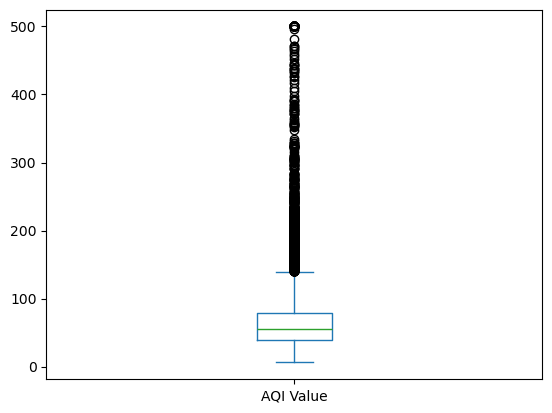

In [151]:
#Generating boxplot to find outliers
result['AQI Value'].plot(kind='box')

In [153]:
#As thier are no outliers we need to replace the NaN with mean
x1=result["AQI Value"].mean()
x1

72.01086817542513

In [155]:
#Replacing with mean
result["AQI Value"]=result["AQI Value"].fillna(x1)
result

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [157]:
#Checking how many NaN values are in AQI Category column
result[result["AQI Category"].isna()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,87.500000


In [159]:
#Checking most repeated AQI Category using mode
print(result["AQI Category"].mode()[0])
#Replace with mode
result["AQI Category"].fillna(result["AQI Category"].mode()[0], inplace=True)
result

Good


C:\Users\gmsjp\AppData\Local\Temp\ipykernel_7836\1503199153.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["AQI Category"].fillna(result["AQI Category"].mode()[0], inplace=True)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [161]:
#Checking how many NaN values are in "CO AQI Value" column
result[result["CO AQI Value"].isna()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,87.500000


<Axes: >

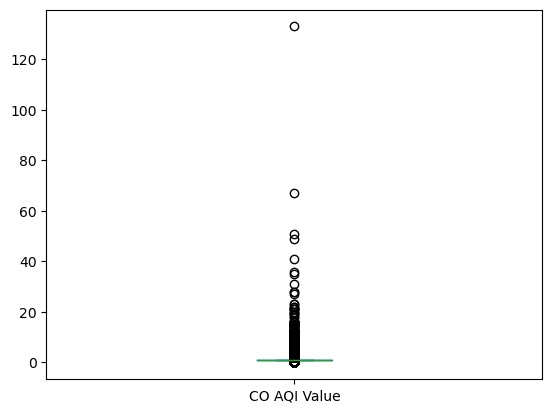

In [163]:
#Generating boxplot to find outliers
result["CO AQI Value"].plot(kind='box')

In [165]:
#As thier are outliers we need to replace the NaN with median
x2=result["CO AQI Value"].median()
x2


1.0

In [167]:
#Replacing with median
result["CO AQI Value"]=result["CO AQI Value"].fillna(x2)
result

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [169]:
#Checking how many NaN values are in "CO AQI Category" column
result[result["CO AQI Category"].isna()]


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,Good,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,87.500000


In [171]:
#Cheacking most repeated "CO AQI Category"
print(result["CO AQI Category"].mode()[0])
#Replace with mode
result["CO AQI Category"].fillna(result["CO AQI Category"].mode()[0], inplace=True)
result


Good


C:\Users\gmsjp\AppData\Local\Temp\ipykernel_7836\2508754985.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["CO AQI Category"].fillna(result["CO AQI Category"].mode()[0], inplace=True)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [173]:
#Checking how many NaN values are in "Ozone AQI Value" column
result[result["Ozone AQI Value"].isna()]


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,Good,1.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,,87.500000


<Axes: >

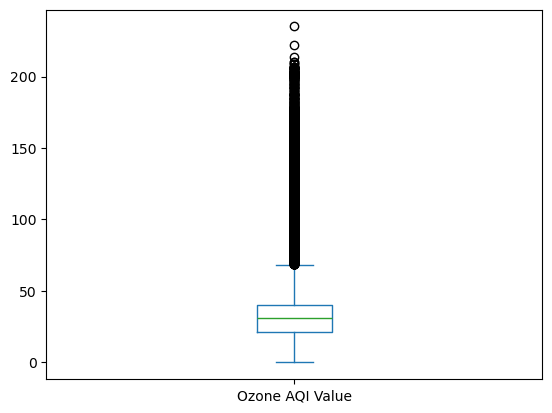

In [175]:
#Generating boxplot to find outliers
result['Ozone AQI Value'].plot(kind='box')


In [177]:
#As thier are outliers we need to replace the NaN with median
x3=result['Ozone AQI Value'].median()
x3



31.0

In [179]:
#Replacing with median
result['Ozone AQI Value']=result['Ozone AQI Value'].fillna(x3)
result


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [181]:
#Checking how many NaN values are in "Ozone AQI Category" column
result[result["Ozone AQI Category"].isna()]


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,Good,1.0,Good,31.0,NaN,NaN,NaN,NaN,NaN,,87.500000


In [183]:
#Checking most repeated "Ozone AQI Category"
print(result["Ozone AQI Category"].mode()[0])


Good


In [185]:
#Replace with mode
result["Ozone AQI Category"].fillna(result["City"].mode()[0], inplace=True)
result


C:\Users\gmsjp\AppData\Local\Temp\ipykernel_7836\2147790394.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["Ozone AQI Category"].fillna(result["City"].mode()[0], inplace=True)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [187]:
#Checking how many NaN values are in "NO2 AQI Value" column
result[result["NO2 AQI Value"].isna()]


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,Good,1.0,Good,31.0,Albany,NaN,NaN,NaN,NaN,,87.500000


<Axes: >

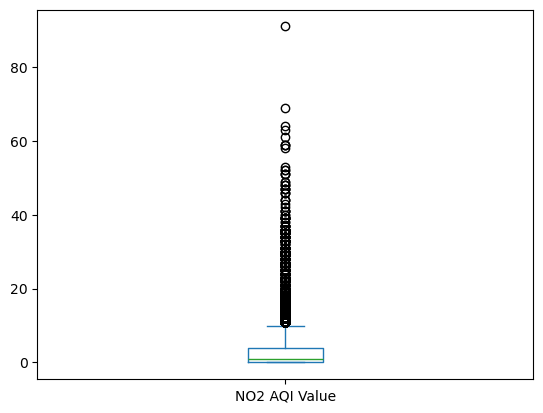

In [189]:
#Generating boxplot to find outliers
result["NO2 AQI Value"].plot(kind='box')


In [190]:
#As thier are outliers we need to replace the NaN with median
x4=result["NO2 AQI Value"].mean()
x4


3.0633337595362913

In [193]:
#Replacing with mean
result["NO2 AQI Value"]=result["NO2 AQI Value"].fillna(x4)
result



,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.000000,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.000000,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.000000,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.000000,Good,39.0,Good,NaN,NaN


In [195]:
#Checking how many NaN values are in "NO2 AQI Category" column
result[result["NO2 AQI Category"].isna()]


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,Good,1.0,Good,31.0,Albany,3.063334,NaN,NaN,NaN,,87.500000


In [197]:
#Checking most repeated "NO2 AQI Category"
print(result["NO2 AQI Category"].mode()[0])


Good


In [199]:
#Replace with mode
result["NO2 AQI Category"].fillna(result["NO2 AQI Category"].mode()[0], inplace=True)
result



C:\Users\gmsjp\AppData\Local\Temp\ipykernel_7836\4261742173.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["NO2 AQI Category"].fillna(result["NO2 AQI Category"].mode()[0], inplace=True)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.000000,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.000000,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.000000,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.000000,Good,39.0,Good,NaN,NaN


In [201]:
#Checking how many NaN values are in "PM2.5 AQI Value" column
result[result["PM2.5 AQI Value"].isna()]


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,NaN,NaN,,87.500000


<Axes: >

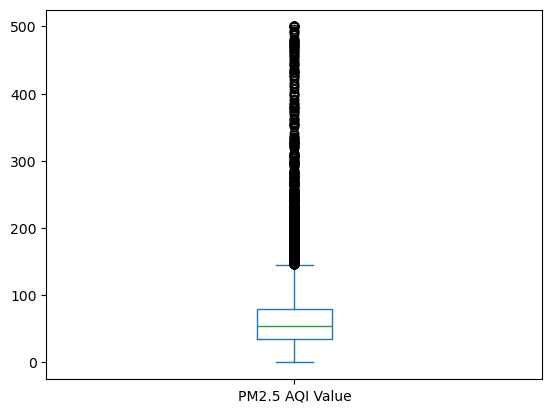

In [203]:
#Generating boxplot to find outliers
result['PM2.5 AQI Value'].plot(kind='box')

In [205]:
#As thier are no outliers we need to replace the NaN with mean
x5=result["PM2.5 AQI Value"].mean()
x5


68.51975450709628

In [207]:
#Replacing with mean
result["PM2.5 AQI Value"]=result["PM2.5 AQI Value"].fillna(x5)
result

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.000000,Good,54.000000,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.000000,Good,45.000000,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.000000,Good,30.000000,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.000000,Good,39.000000,Good,NaN,NaN


In [209]:
#Checking how many NaN values are in "PM2.5 AQI Category" column
result[result["PM2.5 AQI Category"].isna()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3958,Zambia,Mansa,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Luapula Province,25.000000
3959,Zimbabwe,Bindura,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,Mashonaland Central Province,75.000000
3960,Zimbabwe,Bulawayo,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,,71.428571
3961,Zimbabwe,Harare,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,NaN,,87.500000


In [211]:
#Checking most repeated "PM2.5 AQI Category"
print(result["PM2.5 AQI Category"].mode()[0])


Good


In [213]:
#Replace with mode
result["PM2.5 AQI Category"].fillna(result["PM2.5 AQI Category"].mode()[0], inplace=True)
result


C:\Users\gmsjp\AppData\Local\Temp\ipykernel_7836\2681149806.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["PM2.5 AQI Category"].fillna(result["PM2.5 AQI Category"].mode()[0], inplace=True)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.000000,Good,54.000000,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.000000,Good,45.000000,Good,NaN,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.000000,Good,30.000000,Good,NaN,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.000000,Good,39.000000,Good,NaN,NaN


In [215]:
#Checking how many NaN values are in "CO AQI Category" column
result[result["Region"].isna()]


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
3963,Afghanistan,Acin,62.0,Moderate,0.0,Good,46.0,Good,0.0,Good,62.0,Moderate,NaN,NaN
3964,Afghanistan,Anar Darreh,126.0,Unhealthy for Sensitive Groups,1.0,Good,42.0,Good,0.0,Good,126.0,Unhealthy for Sensitive Groups,NaN,NaN
3965,Afghanistan,Andarab,104.0,Unhealthy for Sensitive Groups,0.0,Good,34.0,Good,0.0,Good,104.0,Unhealthy for Sensitive Groups,NaN,NaN
3966,Afghanistan,Asadabad,131.0,Unhealthy for Sensitive Groups,1.0,Good,43.0,Good,0.0,Good,131.0,Unhealthy for Sensitive Groups,NaN,NaN
3967,Afghanistan,Asmar,151.0,Unhealthy,2.0,Good,48.0,Good,1.0,Good,151.0,Unhealthy,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.0,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,NaN,NaN
27422,United States of America,Yokosuka,69.0,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,NaN,NaN
27423,United States of America,Ystad,37.0,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,NaN,NaN
27424,United States of America,Zanzibar,39.0,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,NaN,NaN


In [217]:
#Checking most repeated " Region"
print(result["Region"].mode()[0])


In [219]:
result['Region'] = result['Region'].fillna('Unknown')
result

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.000000,Good,54.000000,Moderate,Unknown,NaN
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.000000,Good,45.000000,Good,Unknown,NaN
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.000000,Good,30.000000,Good,Unknown,NaN
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.000000,Good,39.000000,Good,Unknown,NaN


In [221]:
#Checking how many NaN values are in "WaterPollution" column
result[result["WaterPollution"].isna()]


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
3963,Afghanistan,Acin,62.0,Moderate,0.0,Good,46.0,Good,0.0,Good,62.0,Moderate,Unknown,NaN
3964,Afghanistan,Anar Darreh,126.0,Unhealthy for Sensitive Groups,1.0,Good,42.0,Good,0.0,Good,126.0,Unhealthy for Sensitive Groups,Unknown,NaN
3965,Afghanistan,Andarab,104.0,Unhealthy for Sensitive Groups,0.0,Good,34.0,Good,0.0,Good,104.0,Unhealthy for Sensitive Groups,Unknown,NaN
3966,Afghanistan,Asadabad,131.0,Unhealthy for Sensitive Groups,1.0,Good,43.0,Good,0.0,Good,131.0,Unhealthy for Sensitive Groups,Unknown,NaN
3967,Afghanistan,Asmar,151.0,Unhealthy,2.0,Good,48.0,Good,1.0,Good,151.0,Unhealthy,Unknown,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.0,Moderate,0.0,Good,36.0,Good,2.0,Good,54.0,Moderate,Unknown,NaN
27422,United States of America,Yokosuka,69.0,Moderate,1.0,Good,69.0,Moderate,2.0,Good,45.0,Good,Unknown,NaN
27423,United States of America,Ystad,37.0,Good,1.0,Good,37.0,Good,1.0,Good,30.0,Good,Unknown,NaN
27424,United States of America,Zanzibar,39.0,Good,1.0,Good,20.0,Good,0.0,Good,39.0,Good,Unknown,NaN


<Axes: >

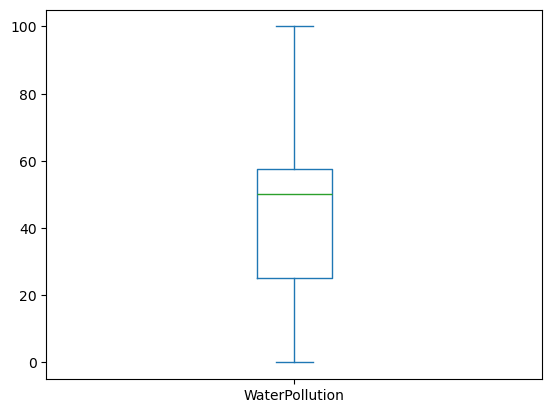

In [223]:
#Generating boxplot to find outliers
result['WaterPollution'].plot(kind='box')

In [225]:
#As thier are no outliers we need to replace the NaN with mean
x6=result["WaterPollution"].mean()
x6


44.63537214186172

In [227]:
#Replacing with mean
result["WaterPollution"]=result["WaterPollution"].fillna(x6)
result

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution
0,Afghanistan,Andkhoy,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Faryab,50.000000
1,Afghanistan,Farah,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Farah,0.000000
2,Afghanistan,Herat,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Herat,31.250000
3,Afghanistan,Kabul,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Kabul,81.060606
4,Afghanistan,Kandahar,72.010868,Good,1.0,Good,31.0,Albany,3.063334,Good,68.519755,Good,Kandahar,75.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27421,United States of America,Worthing,54.000000,Moderate,0.0,Good,36.0,Good,2.000000,Good,54.000000,Moderate,Unknown,44.635372
27422,United States of America,Yokosuka,69.000000,Moderate,1.0,Good,69.0,Moderate,2.000000,Good,45.000000,Good,Unknown,44.635372
27423,United States of America,Ystad,37.000000,Good,1.0,Good,37.0,Good,1.000000,Good,30.000000,Good,Unknown,44.635372
27424,United States of America,Zanzibar,39.000000,Good,1.0,Good,20.0,Good,0.000000,Good,39.000000,Good,Unknown,44.635372


In [235]:
#Rechecking if their are any nan values
result.isna().sum()

Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
Region                0
WaterPollution        0
dtype: int64

In [239]:
#Checking if their are any duplicate values
result[result.duplicated()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Region,WaterPollution


In [243]:
#As thier are no any duplicate values we don't need to reset the index

## GENERATING GRAPHS

In [245]:
"""1. Identifies the top 10 most polluted cities and visualizes them with a bar chart.
2. Shows the distribution of AQI values using a histogram.
3. Creates a correlation heatmap to analyze the relationship between pollutants."""

'1. Identifies the top 10 most polluted cities and visualizes them with a bar chart.\n2. Shows the distribution of AQI values using a histogram.\n3. Creates a correlation heatmap to analyze the relationship between pollutants.'

In [250]:
# Top 10 most polluted cities based on AQI Value
top_cities = result.groupby("City")["AQI Value"].mean().sort_values(ascending=False).head(10)
top_cities

City
Niwari       500.0
Barkhera     500.0
Didwana      500.0
Bilari       500.0
Sujangarh    500.0
Dhuri        500.0
Aonla        500.0
Pilibanga    500.0
Hasanpur     500.0
Kanina       500.0
Name: AQI Value, dtype: float64

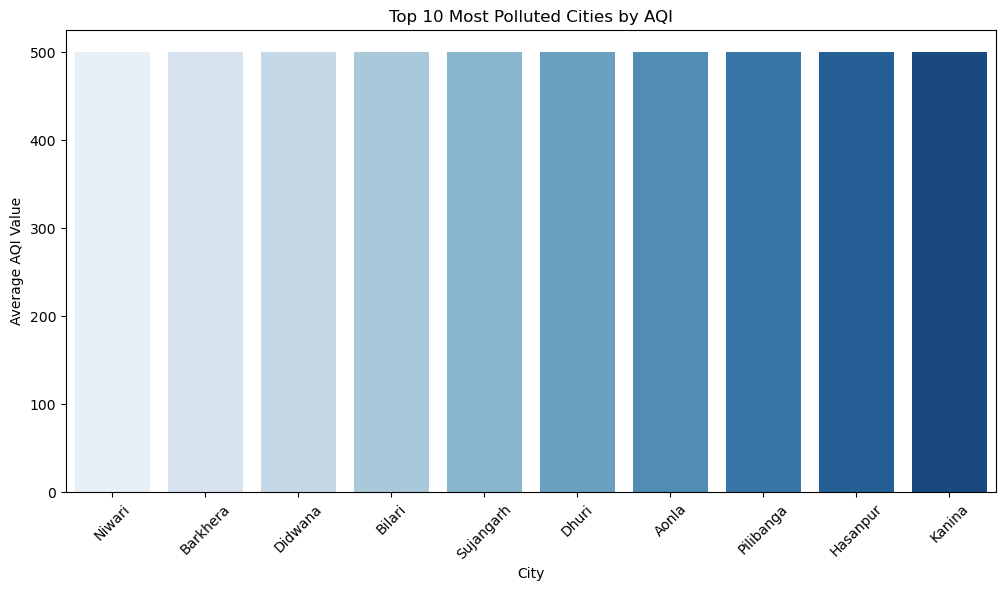

In [268]:
# Bar plot for most polluted cities
plt.figure(figsize=(12, 6))
sns.barplot(x=top_cities.index, y=top_cities.values, hue=top_cities.index, palette="Blues", legend=False)
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Average AQI Value")
plt.title("Top 10 Most Polluted Cities by AQI")
plt.show()

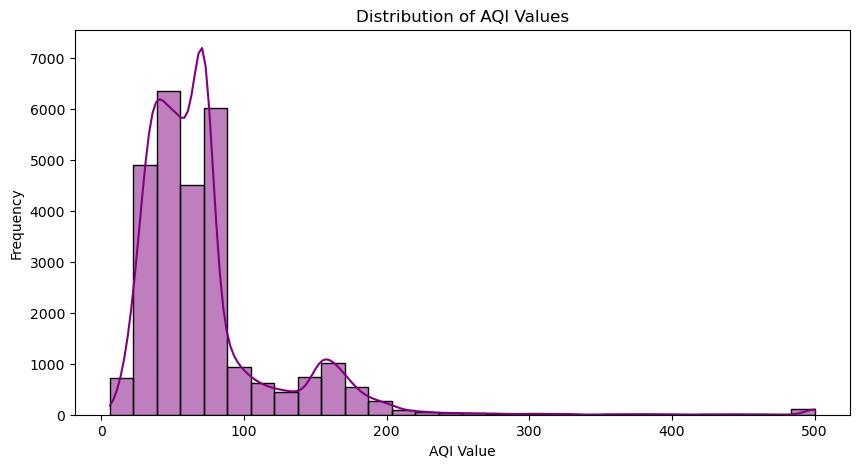

In [274]:
# Distribution of AQI values
plt.figure(figsize=(10, 5))
sns.histplot(result["AQI Value"], bins=30, kde=True, color="purple")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.title("Distribution of AQI Values")
plt.show()

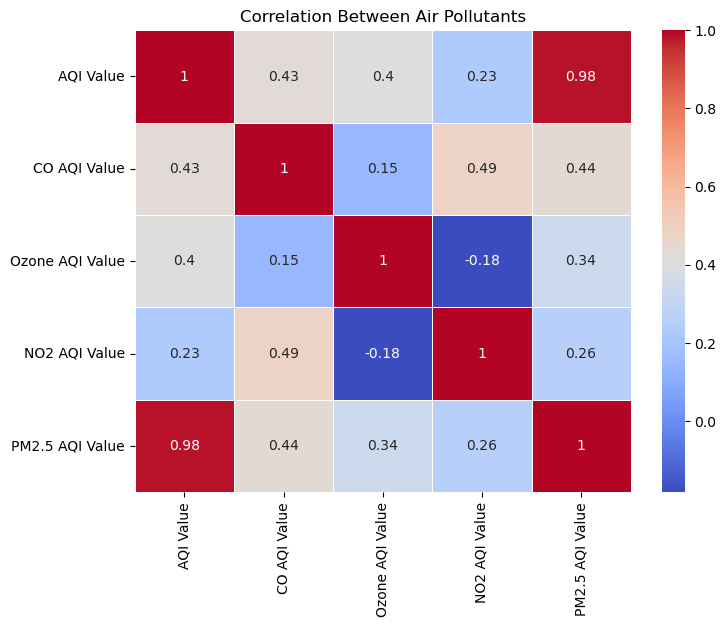

In [276]:
# Correlation heatmap of pollutants
plt.figure(figsize=(8, 6))
pollutants = ["AQI Value", "CO AQI Value", "Ozone AQI Value", "NO2 AQI Value", "PM2.5 AQI Value"]
sns.heatmap(result[pollutants].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Air Pollutants")
plt.show()

In [278]:
result.columns = result.columns.str.replace('"', '').str.strip()
result["Region"] = result["Region"].str.replace('"', '').str.strip()
result["Country"] = result["Country"].str.replace('"', '').str.strip()

sns.set_style("whitegrid")


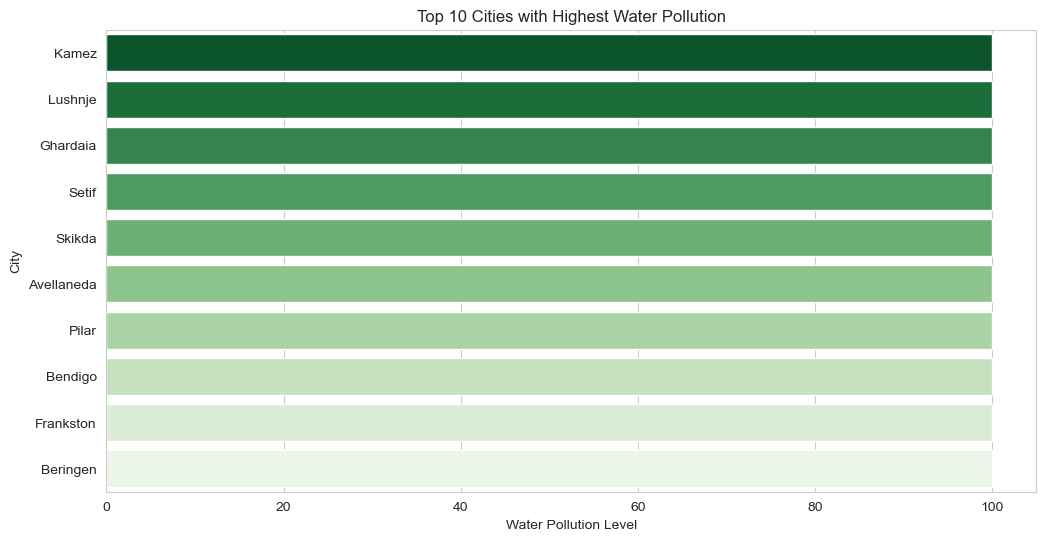

In [280]:
# 1. Top 10 Cities with the Highest Water Pollution
top_cities = result.nlargest(10, "WaterPollution")
plt.figure(figsize=(12, 6))
sns.barplot(
    y=top_cities["City"], 
    x=top_cities["WaterPollution"], 
    hue=top_cities["City"],  # Assign the y-variable to hue
    palette="Greens_r",
    legend=False  # Suppress the automatic legend
)
plt.xlabel("Water Pollution Level")
plt.ylabel("City")
plt.title("Top 10 Cities with Highest Water Pollution")
plt.show()

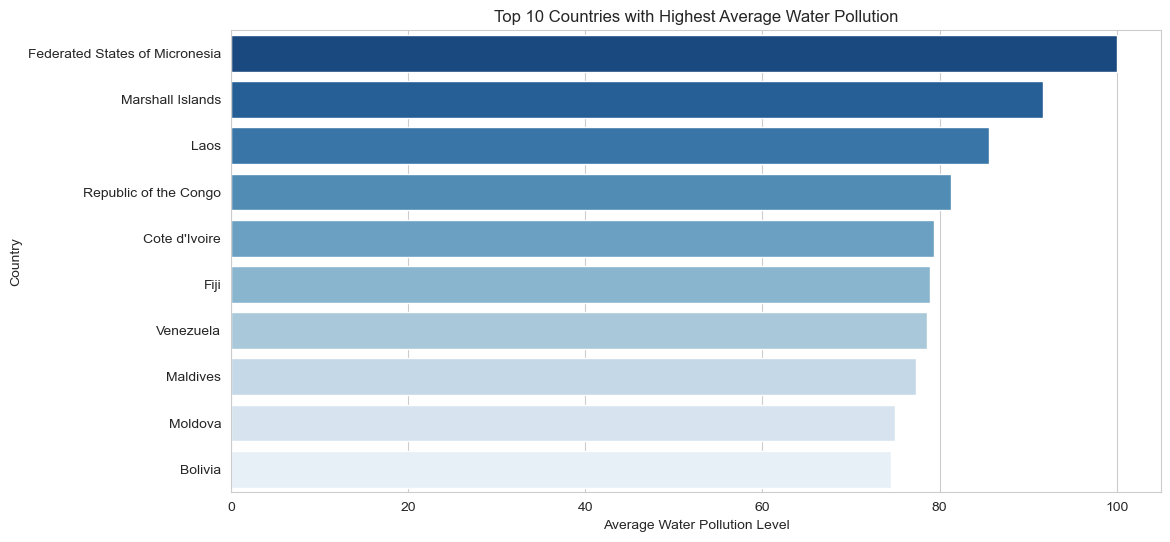

In [282]:
# 2. Top 10 Countries with the Highest Average Water Pollution
country_avg = result.groupby("Country")["WaterPollution"].mean().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(
    y=country_avg.index, 
    x=country_avg.values, 
    hue=country_avg.index,  # Assign the y-variable to hue
    palette="Blues_r",
    legend=False  # Suppress the automatic legend
)

plt.xlabel("Average Water Pollution Level")
plt.ylabel("Country")
plt.title("Top 10 Countries with Highest Average Water Pollution")
plt.show()

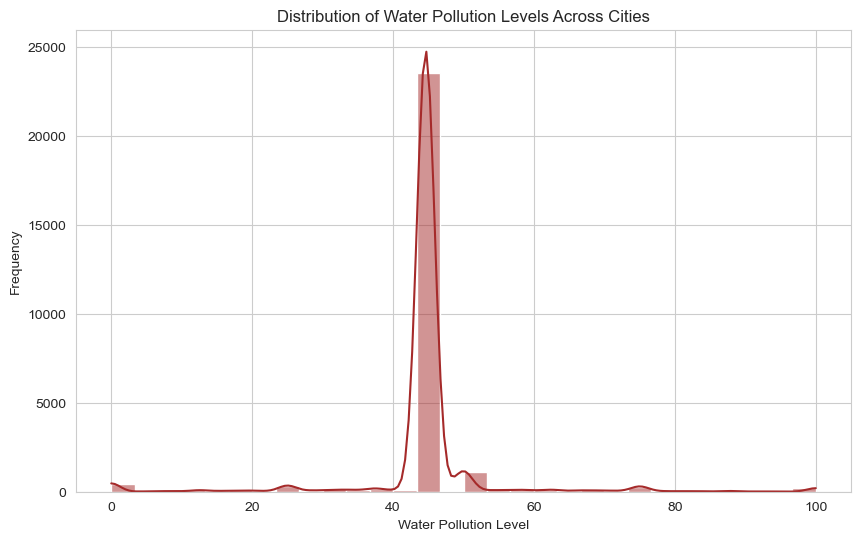

In [284]:
# 3. Distribution of Water Pollution Levels
plt.figure(figsize=(10, 6))
sns.histplot(result["WaterPollution"], bins=30, kde=True, color="brown")
plt.xlabel("Water Pollution Level")
plt.ylabel("Frequency")
plt.title("Distribution of Water Pollution Levels Across Cities")
plt.show()